<a href="https://colab.research.google.com/github/Santiago-Parada/Public-Projects/blob/main/embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sentence_transformers import SentenceTransformer
doc_es=pd.read_parquet("sample_data/imss_data.parquet")
# nlp_es = load("es_core_news_sm")


model = SentenceTransformer("hiiamsid/sentence_similarity_spanish_es")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [2]:

embeddings = model.encode(doc_es["documento"].tolist())

doc_es["embedding"] = list(embeddings)
# print(embeddings.shape)

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=1234)

doc_es["cluster"] = kmeans.fit_predict(embeddings)

In [4]:
for c in range(10):
    print(f"\nCluster {c}")
    print(doc_es[doc_es.cluster == c]["documento"].head(5).tolist())


Cluster 0
['I.1. Entorno económico y composición del aseguramiento Desde su creación en 1943, el IMSS tiene el mandato de proteger a las personas trabajadoras y sus familias mediante las prestaciones de seguridad social establecidas en la Ley del Seguro Social (LSS). La afiliación y el salario asociado, están vinculados con el desempeño de la economía nacional. Por otro lado, se señalan diversas estrategias implementadas para ampliar la base de incorporación y para mejorar la recuperación de las cuotas obrero patronales. I.1.1. El ciclo económico y la formalización del empleo Los Criterios Generales de Política Económica 2024 destacaron como ejes fundamentales: el fortalecimiento de la red de protección social en favor de grupos de la población desatendidos y en condición de pobreza, y las reformas en materia laboral y de política salarial, entre otros. Para 2024 se estimó un crecimiento real anual de la economía mexicana de entre 2.5% y 3.5%, con una estimación puntual del Producto I

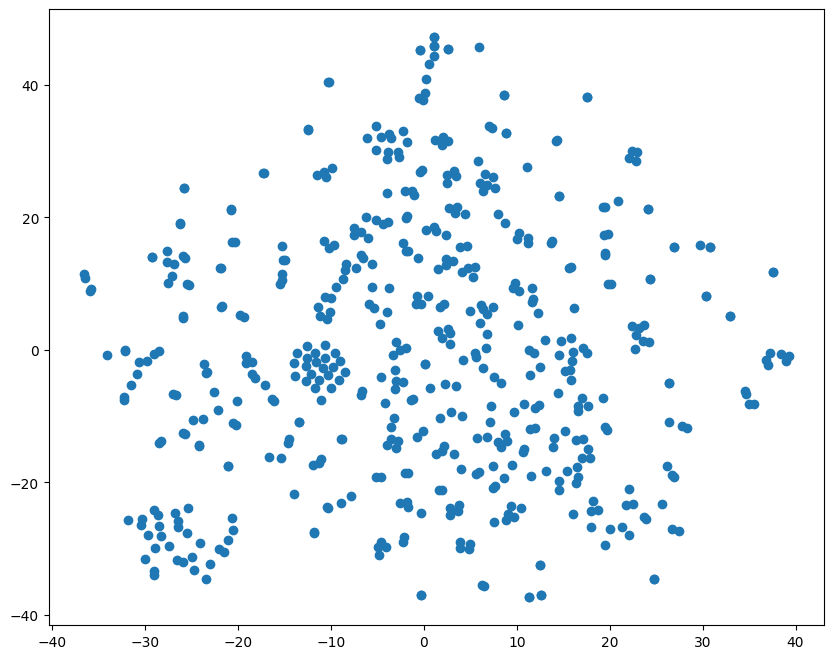

In [5]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

X2 = TSNE(
    n_components=2,
    random_state=1234,
    perplexity=30
).fit_transform(embeddings)

plt.figure(figsize=(10,8))
plt.scatter(X2[:,0], X2[:,1])
plt.show()

In [6]:


X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    doc_es["seccion"],
    test_size=0.3,
    random_state=1234,
)

modelo = RandomForestClassifier( n_estimators=150,
    max_samples=0.6,
    bootstrap=True,
    random_state=1234,
    n_jobs=-1)

modelo.fit(X_train, y_train)

print(modelo.score(X_test, y_test))

0.2721518987341772
